In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

from matplotlib.patches import Patch
from collections import Counter

def rSubset(arr, r):
    return list(combinations(arr, r))

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
contacts_unique_pro_unb=pd.read_csv('../../../data/intra_protein_contacts/state_specific_contacts/UNIQ_CONTACTS_DATA_PRE_VS_UNB.csv',
                                index_col=0)
contacts_unique_pro_unb


,Ri,Ri region,Rj,Rj region,Unique to PRE or UNB
0,4,M Nterm,9,M Nterm,PRE
1,4,M Nterm,39,M L3,PRE
2,5,M Nterm,9,M Nterm,PRE
3,8,M Nterm,12,M Nterm,PRE
4,10,M Nterm,36,M B1,PRE
...,...,...,...,...,...
14,122,R Ext Cterm,123,R Ext Cterm,PRE
15,122,R Ext Cterm,124,R Ext Cterm,PRE
16,123,R Ext Cterm,124,R Ext Cterm,PRE
17,123,R Ext Cterm,125,R Ext Cterm,PRE


In [4]:
cl_ri=[]

for i in contacts_unique_pro_unb['Ri region']:
    if 'HP' in i:
        cl_ri.append('BPM')
    elif 'R ' in i:
        cl_ri.append('REST')
    elif 'M ' in i:
        cl_ri.append('MTM')

        
cl_rj=[]

for i in contacts_unique_pro_unb['Rj region']:
    if 'HP' in i:
        cl_rj.append('BPM')
    elif 'R ' in i:
        cl_rj.append('REST')
    elif 'M ' in i:
        cl_rj.append('MTM')
        
        
contacts_unique_pro_unb['Ri Cl']=cl_ri
contacts_unique_pro_unb['Rj Cl']=cl_rj

contacts_unique_pro_unb

,Ri,Ri region,Rj,Rj region,Unique to PRE or UNB,Ri Cl,Rj Cl
0,4,M Nterm,9,M Nterm,PRE,MTM,MTM
1,4,M Nterm,39,M L3,PRE,MTM,MTM
2,5,M Nterm,9,M Nterm,PRE,MTM,MTM
3,8,M Nterm,12,M Nterm,PRE,MTM,MTM
4,10,M Nterm,36,M B1,PRE,MTM,MTM
...,...,...,...,...,...,...,...
14,122,R Ext Cterm,123,R Ext Cterm,PRE,REST,REST
15,122,R Ext Cterm,124,R Ext Cterm,PRE,REST,REST
16,123,R Ext Cterm,124,R Ext Cterm,PRE,REST,REST
17,123,R Ext Cterm,125,R Ext Cterm,PRE,REST,REST


In [5]:
def index_ret(segment, res_n):
    if segment=='MTM':
        return(MEM_RES.index(res_n))
    elif segment=='BPM':
        return(pock_res.index(res_n))
    elif segment=='REST':
        return(rest_res.index(res_n))
    
MEM_RES=[1,2,3,4,5,6,7,8,9,10,12,36,37,38,39,40,41,42,43,44,46,80,82,84,85,112,114,115,116,117,118,119]
pock_res=[19,23,32,34,51,53,108,35,52,54,55,58,63,66,67,70]
rest_res=[i for i in range(1,120) if i not in MEM_RES+pock_res]



membrane_binding_region=[('N-Terminal',0,10),('B1',11,12),('L3',13,20),
                        ('B3',21,22),('L6',23,24),
                         ('B4',25,26),('C-Terminal',27,32)]
rest_region=[('H2',1,12),('L2',13,15),('B1',16,18),('L3',19,23),
            ('L4',24,26),('H3',27,33),('L5',34,42),('L6',44,53),('H4',54,61),
            ('L7',62,66),('B4',67,70)]
pockets_L=[('HP1',0,7),('HP2',8,15)]

In [6]:
#1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 37, 38, 39, 40, 41, 42, 43, 45, 46, 119
LC3B_segments={'M Nterm':[1,2,3,4,5,6,7,8,9,10,12],
               'M B1':[36,37],
               'M L3':[38,39,40,41,42,43,44,46],
               'M B3':[80,82],
               'M L6':[84,85],
               'M B4': [112,114],
               'M Cterm': [115,116,117,118,119,120],
               
               'HP1':[19,23,32,34,51,53,108],
               'HP2':[35,52,54,55,58,63,66,67,70],
               
               'R ':[81,11], #OUTLYING NTERM B3 residues
               
               'R H2':[13,14,15,16,17,18,20,21,22,24,25,26],
               'R L2':[27,28,29],
               'R B1':[30,31,33],
               'R L3':[45,47,48,49,50],
               'R L4':[56,57,59],
               'R H3':[60,61,62,64,65,68,69],
               'R L5':[71,72,73,74,75,76,77,78,79],
               'R L6':[83,86,87,88,89,89,90,91,92,93,94],
               'R H4':[i for i in range(95,103)],
               'R L7':[i for i in range(103,108)],
               'R B4':[i for i in range(109,114)],
              'R Ext Cterm': [i for i in range (121,126)]}

cont_spec_data_ext_data=contacts_unique_pro_unb


In [8]:
ss_seg_needed=['H2','H3','H4','L2','B1','B3','B4','L5','L6','L7','Cterm']
ss_seg_count_unb=[]
for seg in ss_seg_needed:
    counter=0
    for i,j,k,l,m in zip(cont_spec_data_ext_data['Ri region'],
                  cont_spec_data_ext_data['Rj region'],
                      cont_spec_data_ext_data['Ri'],
                      cont_spec_data_ext_data['Rj'],
                       cont_spec_data_ext_data['Unique to PRE or UNB']):
        if m=='UNB':
            if seg in i or seg in j:
                counter=counter+1
    ss_seg_count_unb.append(counter)

In [9]:
ss_seg_needed=['H2','H3','H4','L2','B1','B3','B4','L5','L6','L7','Cterm']
ss_seg_count_pre=[]
for seg in ss_seg_needed:
    counter=0
    for i,j,k,l,m in zip(cont_spec_data_ext_data['Ri region'],
                  cont_spec_data_ext_data['Rj region'],
                      cont_spec_data_ext_data['Ri'],
                      cont_spec_data_ext_data['Rj'],
                       cont_spec_data_ext_data['Unique to PRE or UNB']):
        if m=='PRE':
            if seg in i or seg in j:
                
                counter=counter+1
    ss_seg_count_pre.append(counter)

In [13]:
# without Extended C-term
ss_seg_needed=['H2','H3','H4','L2','B1','B3','B4','L5','L6','L7','Cterm']
ss_seg_count_pre_no_ext_ct=[]
for seg in ss_seg_needed:
    counter=0
    for i,j,k,l,m in zip(cont_spec_data_ext_data['Ri region'],
                  cont_spec_data_ext_data['Rj region'],
                      cont_spec_data_ext_data['Ri'],
                      cont_spec_data_ext_data['Rj'],
                       cont_spec_data_ext_data['Unique to PRE or UNB']):
        if m=='PRE':
            if seg in i or seg in j:
                if i!='R Ext Cterm' and j!='R Ext Cterm':
                    counter=counter+1
    
    ss_seg_count_pre_no_ext_ct.append(counter)

In [10]:
ss_seg_count_pre[-1]=ss_seg_count_pre[-1]-10 # removing intra cterm cont since these contacts are shared b/w i and i+1


In [11]:
font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }

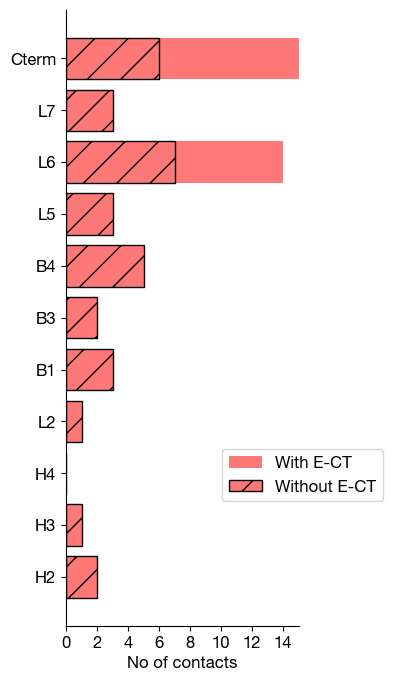

In [14]:
fig, ax = plt.subplots(figsize=(3,8))

ax.barh(ss_seg_needed, ss_seg_count_pre,color='#FF7878',label='With E-CT')
b2=ax.barh(ss_seg_needed, ss_seg_count_pre_no_ext_ct,color='#FF7878',hatch="/",
           label='Without E-CT')

for bar in b2:
    bar.set_edgecolor("black")
    bar.set_linewidth(1)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)
# ax.spines['left'].set_visible(False)

# ax.set_yticks([])
# ax.set_xticks([])
ax.set_xlim(0,15)

ax.set_yticks([i for i in range(len(ss_seg_needed))],
             ss_seg_needed,fontdict=font)

ax.set_xticks([0,2,4,6,8,10,12,14],[0,2,4,6,8,10,12,14]
              ,fontdict=font)

ax.set_xlabel('No of contacts',
             fontdict=font)
ax.legend(prop=rs, 
          bbox_to_anchor=(0.4,0.3,1,0))
plt.savefig('../../../plots/intra_protein_contacts/state_specific_contacts/REST_associated_uniq_contacts_pro_compared_with_unb.png',
           dpi=450, transparent=True)

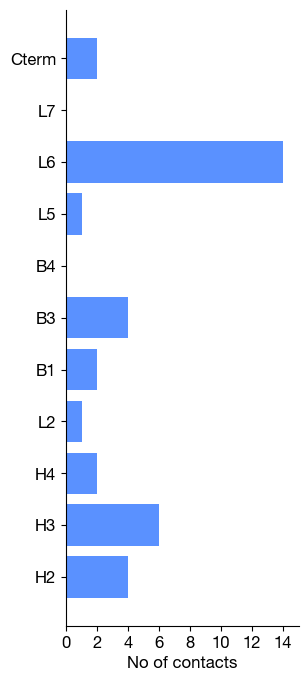

In [31]:
fig, ax = plt.subplots(figsize=(3,8))
ax.barh(ss_seg_needed, ss_seg_count_unb,color='#5A91FF')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)
# ax.spines['left'].set_visible(False)

# ax.set_yticks([])
# ax.set_xticks([])
ax.set_xlim(0,15)

ax.set_yticks([i for i in range(len(ss_seg_needed))],
             ss_seg_needed,fontdict=font)

ax.set_xticks([0,2,4,6,8,10,12,14],[0,2,4,6,8,10,12,14]
              ,fontdict=font)

ax.set_xlabel('No of contacts',
             fontdict=font)

plt.savefig('../../../plots/intra_protein_contacts/state_specific_contacts/REST_associated_uniq_contacts_unb_compared_with_pre.png',
           dpi=450, transparent=True)

In [16]:
#L6 associated contacts

In [22]:
for i,j,k,l,m in zip(cont_spec_data_ext_data['Ri region'],
                  cont_spec_data_ext_data['Rj region'],
                      cont_spec_data_ext_data['Ri'],
                      cont_spec_data_ext_data['Rj'],
                       cont_spec_data_ext_data['Unique to PRE or UNB']):
    if m=="PRE":
        if "L6" in i or "L6" in j:
            print(i,j,k,l,m)

R L6 M B4 83 112 PRE
M L6 R B4 84 111 PRE
M L6 M B4 84 112 PRE
M L6 M Cterm 85 119 PRE
R L6 M Cterm 86 119 PRE
R L6 M Cterm 87 119 PRE
R L6 R L6 90 93 PRE
R L6 R Ext Cterm 83 122 PRE
M L6 R Ext Cterm 84 121 PRE
M L6 R Ext Cterm 84 122 PRE
M L6 R Ext Cterm 84 123 PRE
M L6 R Ext Cterm 84 124 PRE
M L6 R Ext Cterm 85 122 PRE
R L6 R Ext Cterm 86 122 PRE


In [23]:
for i,j,k,l,m in zip(cont_spec_data_ext_data['Ri region'],
                  cont_spec_data_ext_data['Rj region'],
                      cont_spec_data_ext_data['Ri'],
                      cont_spec_data_ext_data['Rj'],
                       cont_spec_data_ext_data['Unique to PRE or UNB']):
    if m=="UNB":
        if "L6" in i or "L6" in j:
            print(i,j,k,l,m)

R H3 R L6 60 92 UNB
R H3 R L6 61 88 UNB
R H3 R L6 61 89 UNB
R H3 R L6 61 90 UNB
R H3 R L6 64 88 UNB
R H3 R L6 64 89 UNB
R L5 R L6 79 89 UNB
M B3 R L6 80 87 UNB
M B3 R L6 80 89 UNB
R  R L6 81 86 UNB
R  R L6 81 89 UNB
M B3 M L6 82 85 UNB
R L6 R L6 87 91 UNB
R L6 R H4 88 102 UNB


In [26]:
#numbers extracted from ABOVE
unb_cont_l6_asso_data=[('L6','H3',6),
                      ('L6', 'L5',1),
                     ('L6','B3',5),
                     ('L6','H4',1),
                      ('L6','L6',1)]

pre_cont_l6_asso_data=[('L6','B4',4),
                     ('L6','H4',1),
                      ('L6','L6',1),
                      #('L6','CT',3+2), #2 contacts FROM residue G120
                       ('L6','CT',3),
                      ('L6', 'E-CT',7)]


In [27]:
def hanging_line(point1, point2):
    import numpy as np

    a = (point2[1] - point1[1])/(np.cosh(point2[0]) - np.cosh(point1[0]))
    b = point1[1] - a*np.cosh(point1[0])
    x = np.linspace(point1[0], point2[0], 100)
    y = a*np.cosh(x) + b

    return (x,y)

def new_parabola_join(p_A,p_B,scaling_factor):
    if p_A<p_B:
        x_points=np.arange(p_A, p_B, 0.001)
    else:
        x_points=np.arange(p_B, p_A, 0.001)
    
    y_points=[]
    for i in x_points:
        y_points.append(((i-p_A)*(i-p_B))*scaling_factor)
    
    return x_points, y_points
def scaler(min_size, max_size, min_val, max_val, sizes):

    scaled_sizes = [(size - min_val) / (max_val - min_val) * (max_size - min_size) + min_size for size in sizes]

    return scaled_sizes



ss_set=['H3','B3','B4','H4','L5','CT','E-CT']
points_all=[(4, ss_set.index(i)) for i in ss_set]

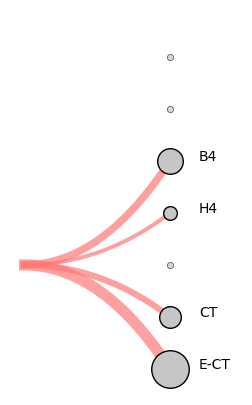

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 5))

line_scales=scaler(2,8, 0,7,[i[2] for i in pre_cont_l6_asso_data])


counter=0
for p_dat in pre_cont_l6_asso_data:
    counter=counter+1
    if p_dat[0]!=p_dat[1]:
        
        p_=(4, ss_set.index(p_dat[1]))
    
        point1 = [0,p_[0]+0]
        point2 = [1,p_[1]+0]
        x,y = hanging_line(point1, point2)


        ax.plot(x,y, lw=line_scales[counter-1], color='#FF7878',alpha=0.7)



        
marker_scales=scaler(7,27, 0,7,[i[2] for i in pre_cont_l6_asso_data])
counter=0
for p_dat in pre_cont_l6_asso_data:
    counter=counter+1
    if p_dat[0]!=p_dat[1]:   
        p_=(4, ss_set.index(p_dat[1]))
        
        point1 = [1,p_[1]]

        ax.plot(point1[0], point1[1], 'o', color='#C6C6C6',markersize=marker_scales[counter-1],
               markeredgecolor='black')
        ax.text(point1[0]+0.2,point1[1],"%s"%p_dat[1]) 
counter=0
for s_p in range(len(ss_set)):
    ax.scatter(1,s_p, marker='o',s=20, color='#C6C6C6',alpha=0.7,
              edgecolors='black',linewidths=0.5)
        
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(-0.1,1.5)
ax.set_ylim(-0.9,6.5)

ax.invert_yaxis()
plt.savefig('../../../plots/intra_protein_contacts/state_specific_contacts/L6_associated_contacts_pre_compared_with_unb.png',
           dpi=450,bbox_inches='tight',
           transparent=True)


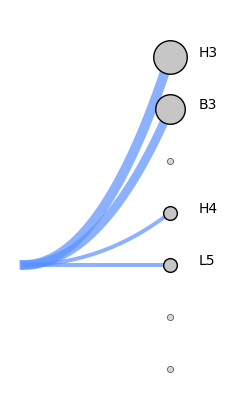

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 5))

line_scales=scaler(2,8, 0,7,[i[2] for i in unb_cont_l6_asso_data])


counter=0
for p_dat in unb_cont_l6_asso_data:
    counter=counter+1
    if p_dat[0]!=p_dat[1]:
        
        p_=(4, ss_set.index(p_dat[1]))
    
        point1 = [0,p_[0]+0]
        point2 = [1,p_[1]+0]
        x,y = hanging_line(point1, point2)


        ax.plot(x,y, lw=line_scales[counter-1], color='#5A91FF',alpha=0.7)



        
marker_scales=scaler(7,27, 0,7,[i[2] for i in unb_cont_l6_asso_data])
counter=0
for p_dat in unb_cont_l6_asso_data:
    counter=counter+1
    if p_dat[0]!=p_dat[1]:   
        p_=(4, ss_set.index(p_dat[1]))
        
        point1 = [1,p_[1]]

        ax.plot(point1[0], point1[1], 'o', color='#C6C6C6',markersize=marker_scales[counter-1],
               markeredgecolor='black')
        ax.text(point1[0]+0.2,point1[1],"%s"%p_dat[1]) 
counter=0
for s_p in range(len(ss_set)):
    ax.scatter(1,s_p,s=20, facecolor='#C6C6C6',alpha=0.7,
              edgecolors='black',linewidths=0.5)
        
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(-0.1,1.5)
ax.set_ylim(-0.9,6.5)
ax.invert_yaxis()
plt.savefig('../../../plots/intra_protein_contacts/state_specific_contacts/L6_associated_contacts_unb_compared_with_pre.png',
           dpi=450,bbox_inches='tight',
           transparent=True)

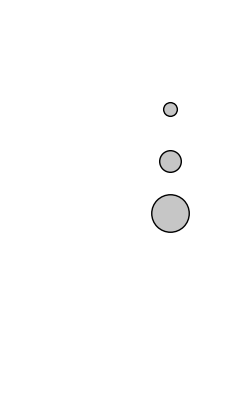

In [30]:
fig, ax = plt.subplots(figsize=(3, 5))
marker_scales=scaler(7,27, 0,7,
                     [i for i in [1,3,7]])

ax.plot(1,1, 
           marker='o', 
           markersize=marker_scales[0],color='#C6C6C6',
       markeredgecolor='black')

ax.plot(1,2, 
           marker='o', 
           markersize=marker_scales[1],color='#C6C6C6',
       markeredgecolor='black')

ax.plot(1,3, 
           marker='o', 
           markersize=marker_scales[2],color='#C6C6C6',
       markeredgecolor='black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(-0.1,1.5)
ax.set_ylim(-0.9,6.5)
ax.invert_yaxis()

plt.savefig('../../../plots/intra_protein_contacts/state_specific_contacts/L6_associated_contacts_size_bar.png',
           dpi=450,bbox_inches='tight',
           transparent=True)